# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 4 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do problemu wagę przedmiotów, powiększającą koszt rozwiązania o długość trasy od miejsca zakupu do końca trasy pomnożoną przez wagę przedmiotu i stały współczynnik dobrany tak, aby dla przedmiotu średniej wagi jego transport między najbardziej odległymi miastami (w linii prostej) wynosił około 1% ceny. Nie dodawaj tego składnika do funkcji kosztu zaimplementowanej w JuMP, ale uwzględnij go w algorytmie genetycznym. Porównaj jakość rozwiązań uzyskanych przez oba algorytmy z uwzględnieniem wagi i bez.
3. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`. Dane do problemu powinny być generowane tak, aby konsument w zwracanym rozwiązaniu odwiedzał przynajmniej 3 miasta i omijał przynajmniej 2.


In [3]:
import Pkg;
Pkg.add("JuMP")
Pkg.add("GLPK")
Pkg.add("DataFrames")
Pkg.add(name="Evolutionary", version="0.10")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Manifest.toml`


# Broń boże nie ściągajcie najnowszej wersji Evolutionary tylko wersję 0.10.1

# ZADANIE 1

In [4]:
using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k;random_seed=1)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

function generate_random_tpp(n, k,random_seed)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 50
k = 20
X, Y, d, cost_item_city = generate_random_tpp(n, k)

([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  47.07715605583087, 45.74787799446105, 39.31968187864505, 95.05129878297356, 78.35752622358207, 64.99869009136225, 13.167067492229867, 12.318877197601253, 19.319307029658294, 92.85029082227491], [37.858565883918295, 25.984947956264225, 71.67867297426689, 1.0898739765043075, 84.7785926801192, 35.36099955711283, 98.58458165854893, 73.65713555150472, 1.992039852101013, 70.72355934304049  …  84.87369607977678, 61.680928138712, 5.665730912653899, 15.622563304879634, 36.90767228785501, 70.07597765092129, 79.43901471209098, 46.482254570311675, 68.59072330642508, 86.69884288310024], [0.0 61.44219730376061 … 32.13916398865862 96.24866724284715; 61.44219730376061 0.0 … 66.3618156785821 64.80204173406327; … ; 32.13916398865862 66.3618156785821 … 0.0 75.72786522881266; 96.24866724284715 64.80204173406327 … 7

### Metoda iteracyjna

In [5]:
function build_tpp_model(d, n, cost_item_city, m)
    model = Model(GLPK.Optimizer)

    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, z[1:m, 1:n], Bin)

    @objective(model, Min, (sum(d .* x)/2) + sum(cost_item_city .* z))

    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)

    @constraint(model, [k in 1:m], sum(z[k,:]) == 1)
    return model
end

build_tpp_model (generic function with 1 method)

In [6]:
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

subtour (generic function with 1 method)

In [7]:
function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

selected_edges (generic function with 1 method)

In [8]:
subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(JuMP.value.(x))

subtour (generic function with 3 methods)

In [9]:
iterative_model = build_tpp_model(d, n, cost_item_city, k)
optimize!(iterative_model)
@assert is_solved_and_feasible(iterative_model)
time_iterated = solve_time(iterative_model)
cycle = subtour(iterative_model[:x])
while 1 < length(cycle) < n
    println("Found cycle of length $(length(cycle))")
    S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
    @constraint(
        iterative_model,
        sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
    )
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    global time_iterated += solve_time(iterative_model)
    global cycle = subtour(iterative_model[:x])
end

objective_value(iterative_model)

Found cycle of length 3
Found cycle of length 10
Found cycle of length 3
Found cycle of length 3


1569.9524382246184

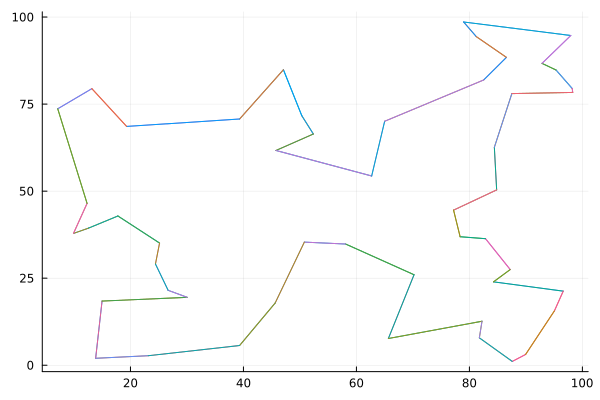

In [10]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, value.(iterative_model[:x]))

In [11]:
function plot_tour_with_shopping(model,X,Y,n,k)
    x_val = value.(model[:x])
    z_val = value.(model[:z])

    p = Plots.plot(legend=false)
    for (i,j) in selected_edges(x_val,n)
        Plots.plot!([X[i],X[j]],[Y[i],Y[j]])
    end

    for i in 1:n
        items_count = sum(z_val[:,i])
        if items_count>0
            msize = 1 + 2*items_count
            Plots.scatter!([X[i]],[Y[i]],
                color=:green,
                markersize=msize,
                label="")
        end
    end
    return p
end

plot_tour_with_shopping (generic function with 1 method)

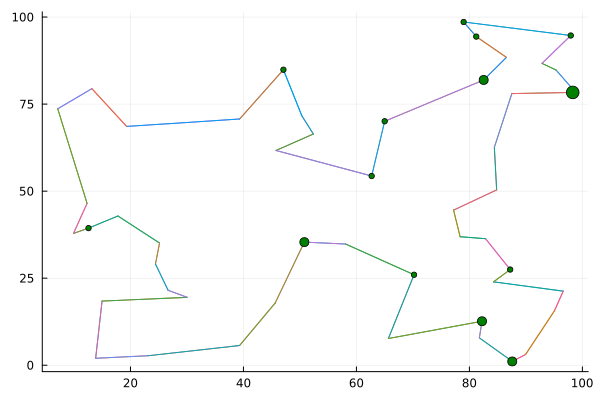

In [12]:
plot_tour_with_shopping(iterative_model,X,Y,n,k)

In [13]:
using DataFrames

function get_shopping_df(model,n,k)
    z_val = value.(model[:z])
    df = DataFrame(Produkt = Int[], Miasto = Int[], Cena = Float64[])

    for p in 1:k, i in 1:n
        if z_val[p,i] > 0.5
            push!(df,(p,i,cost_item_city[p,i]))
        end
    end
    show(df,allrows=true, show_row_number=false,eltypes=false,summary=false)
end

get_shopping_df (generic function with 1 method)

In [14]:
get_shopping_df(iterative_model,n,k)

 Produkt  Miasto  Cena    
──────────────────────────
       1      46  56.9338
       2      33  50.9831
       3      41  51.6528
       4      25  50.391
       5      13  50.3309
       6      16  50.7352
       7      16  50.496
       8      16  51.1225
       9       6  51.108
      10      19  50.1019
      11       2  50.8029
      12       4  50.7244
      13       4  50.9559
      14      40  50.2427
      15      25  52.4366
      16      13  50.8869
      17      22  50.1311
      18       7  52.8782
      19      14  51.0647
      20       6  50.1949

### Metoda genetyczna

In [15]:
using Evolutionary
using Random

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

RP = randperm(20)
iRP = perm_to_inv(RP)
println(RP == inv_to_perm(iRP))

true


In [16]:
function has_subtour(perm::Vector)
    c = 1
    for i in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

has_subtour (generic function with 1 method)

In [17]:
function mutate_swap(recombinant::AbstractVector;rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end


"""

Implementation follows "Genetic Algorithm Solution of the TSP Avoiding Special Crossover and Mutation"
"""
function recombine_tsp(v1::T, v2::T; rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    crossover_point = rand(2:(N-1))
    i1c = vcat(i1[1:crossover_point], i2[(crossover_point+1):N])
    i2c = vcat(i2[1:crossover_point], i1[(crossover_point+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

recombine_tsp

In [18]:
n = 50
k = 50
X, Y, d, cost_item_city = generate_random_tpp(n, k,3)

([27.89882030622046, 20.317568984008272, 12.83965000044105, 97.11027099741459, 96.98050452834212, 18.406095738024607, 98.93628465276494, 60.92799003417528, 58.659656906944015, 17.067480074983  …  53.855467123996334, 26.697171337491387, 63.342986388642416, 57.36653593921965, 67.82864560833886, 93.29911640809125, 5.016246796343804, 30.300728973476843, 87.1284780377437, 16.84827489531644], [0.9728269091585195, 8.602930340366765, 6.226429521836496, 4.1918412561117835, 16.159031898327815, 73.39255792790902, 96.35810075116113, 36.76236658033913, 32.74907388230659, 30.705430283199764  …  39.59463543733348, 35.823662556814725, 4.0530082068680695, 83.49374305977, 40.414224721513214, 16.377729456569078, 9.962618867537042, 45.72324194497441, 79.49969523536635, 20.226951098791467], [0.0 10.756107566470313 … 98.35965333466245 22.19990658062012; 10.756107566470313 0.0 … 97.4168817051919 12.1306990757384; … ; 98.35965333466245 97.4168817051919 … 0.0 91.93783307877511; 22.19990658062012 12.13069907573

In [19]:
x0 = [mod1(i+1, n) for i in 1:n]
function cost(x)
    dist = 0.0
    for i in 1:length(x)
        dist += d[i, x[i]]
    end
    if has_subtour(x)
        dist += 5000
    end
    shopping_cost = sum(minimum(cost_item_city[:, x], dims=2))
    return dist + shopping_cost
end
println("Initial cost: $(cost(x0))")

Initial cost: 5287.31464095069


In [20]:
x_sol = Evolutionary.optimize(
    cost,
    x0,
    GA(; populationSize=500000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.001, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
println(has_subtour(x_sol.minimizer))
println(x_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [2, 3, 4,  ...]
    Minimum:    4405.5850511679055
    Iterations: 53

 * Found with
    Algorithm: GA[P=500000,x=0.9,μ=0.1,ɛ=0.001]

 * Work counters
    Seconds run:   464.523 (vs limit Inf)
    Iterations:    53
    f(x) calls:    27000009



In [21]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    scatter!(X, Y)
    for i in 1:length(x)
        j = x[i]
        Plots.plot!(plot, [X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour (generic function with 1 method)

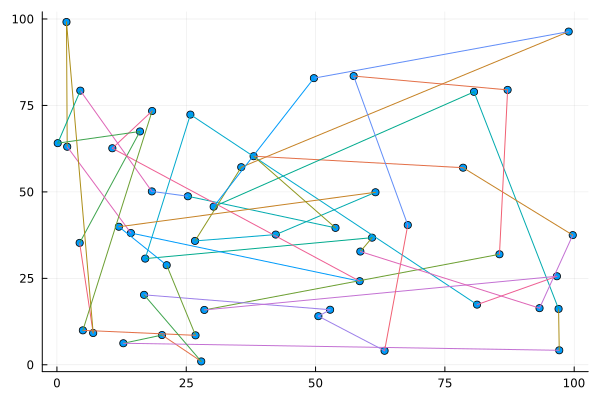

In [22]:
using Plots
plot_tour(X, Y, x_sol.minimizer)

In [23]:
using Printf
function compare_methods(n,k,seed)
    X, Y, d, cost_item_city = generate_random_tpp(n, k,seed)
    time_iterative = @elapsed begin
        iterative_model = build_tpp_model(d, n, cost_item_city, k)
        optimize!(iterative_model)
        @assert is_solved_and_feasible(iterative_model)
        cycle = subtour(iterative_model[:x])
        while 1 < length(cycle) < n
            S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
            @constraint(
                iterative_model,
                sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
            )
            optimize!(iterative_model)
            @assert is_solved_and_feasible(iterative_model)
            cycle = subtour(iterative_model[:x])
        end
    end
    value_iterative = objective_value(iterative_model)

    function cost_local(x)
        dist = 0.0
        for i in 1:length(x)
            dist += d[i, x[i]]
        end
        if has_subtour(x)
            dist += 5000
        end
        shopping_cost = sum(minimum(cost_item_city[:, x], dims=2))
        return dist + shopping_cost
    end


    time_genetic = @elapsed begin
        x0 = [mod1(i+1, n) for i in 1:n]
        x_sol = Evolutionary.optimize(
            cost_local,
            x0,
            GA(; populationSize=25000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.01, crossoverRate=0.9),
            Evolutionary.Options(; iterations=10000)
        )
    end
    value_genetic = Evolutionary.minimum(x_sol)
    @printf("%15.2f | %15.4f | %15.2f | %15.4f | %3d | %3d\n",value_iterative,time_iterative,value_genetic,time_genetic,n,k)
end

compare_methods (generic function with 1 method)

### Porównanie wyników i czasu rozwiązania iteratywnego i genetycznego

In [24]:
println("VALUE ITERATIVE |  TIME ITERATIVE |   VALUE GENETIC |    TIME GENETIC |   N |   K")
compare_methods(50,20,1)
compare_methods(50,20,2)
compare_methods(50,20,3)

compare_methods(50,50,1)
compare_methods(50,50,2)
compare_methods(50,50,3)

compare_methods(100,100,1)
compare_methods(100,100,2)
compare_methods(100,100,3)

VALUE ITERATIVE |  TIME ITERATIVE |   VALUE GENETIC |    TIME GENETIC |   N |   K
        1569.95 |          0.6619 |         3010.32 |          4.0165 |  50 |  20
        1612.07 |          0.7426 |         2796.66 |          7.4031 |  50 |  20
        1679.49 |          0.0986 |         2996.44 |          3.4021 |  50 |  20
        3119.10 |          0.0491 |         4394.42 |         11.7196 |  50 |  50
        3173.94 |          1.2166 |         4465.21 |          6.1563 |  50 |  50
        3236.42 |          0.1470 |         4497.53 |         11.9348 |  50 |  50
        5820.75 |        278.8820 |         9440.39 |         18.1909 | 100 | 100
        5879.53 |         55.8051 |         9169.05 |         18.6870 | 100 | 100
        5887.99 |         19.4246 |         9365.49 |         16.0751 | 100 | 100


# Na 4.0

In [27]:
using JuMP, GLPK, Random, Plots, Printf, Evolutionary

function generate_random_tpp4(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 .* rand(rng, n)
    Y = 100 .* rand(rng, n)
    d = [hypot(X[i] - X[j], Y[i] - Y[j]) for i in 1:n, j in 1:n]
    cost_item_city = 50 .+ 100 .* rand(rng, k, n)
    item_weight = 1 .+ 9 .* rand(rng, k)
    alpha = 0.01 * (sum(cost_item_city) / length(cost_item_city)) / ((sum(item_weight) / length(item_weight)) * maximum(d))
    return X, Y, d, cost_item_city, item_weight, alpha
end

function solve_jump4(d, cost_item_city)
    model = build_tpp_model(d, size(d, 1), cost_item_city, size(cost_item_city, 1))
    optimize!(model)
    cycle = subtour(model[:x])
    while 1 < length(cycle) < size(d, 1)
        S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
        @constraint(model, sum(model[:x][i, j] for (i, j) in S) <= length(cycle) - 1)
        optimize!(model)
        cycle = subtour(model[:x])
    end
    return model
end

function route_from_x4(x)
    n = size(x, 1)
    neighbors = [Int[] for _ in 1:n]
    for i in 1:n-1, j in i+1:n
        if x[i, j] > 0.5
            push!(neighbors[i], j)
            push!(neighbors[j], i)
        end
    end
    route = Int[1]
    previous_city = 0
    current_city = 1
    while true
        next_city = neighbors[current_city][1] == previous_city ? neighbors[current_city][2] : neighbors[current_city][1]
        if next_city == 1
            break
        end
        push!(route, next_city)
        previous_city, current_city = current_city, next_city
    end
    return route
end

function normalize_route4(route)
    first_city_position = findfirst(==(1), route)
    return vcat(route[first_city_position:end], route[1:first_city_position-1])
end

function cycle_suffix_distances4(route, d)
    n = length(route)
    suffix = zeros(Float64, n)
    total = 0.0
    for position in n:-1:1
        next_position = position == n ? 1 : position + 1
        total += d[route[position], route[next_position]]
        suffix[position] = total
    end
    return suffix
end

function evaluate_tpp4(route, d, cost_item_city, item_weight; alpha = 0.0)
    route = normalize_route4(route)
    suffix = cycle_suffix_distances4(route, d)
    travel_cost = suffix[1]
    shopping_cost = 0.0
    transport_cost = 0.0
    shopping_rows = Tuple{Int, Int, Float64, Float64}[]
    for item in 1:size(cost_item_city, 1)
        best_value = Inf
        best_city = route[1]
        best_price = 0.0
        best_transport = 0.0
        for position in 1:length(route)
            city = route[position]
            price = cost_item_city[item, city]
            transport = alpha * item_weight[item] * suffix[position]
            value = price + transport
            if value < best_value
                best_value = value
                best_city = city
                best_price = price
                best_transport = transport
            end
        end
        shopping_cost += best_price
        transport_cost += best_transport
        push!(shopping_rows, (item, best_city, best_price, best_transport))
    end
    total_cost = travel_cost + shopping_cost + transport_cost
    return total_cost, travel_cost, shopping_cost, transport_cost, shopping_rows
end

function pmx_child4(parent_a, parent_b; rng = Random.default_rng())
    n = length(parent_a)
    child = fill(0, n)
    child[1] = 1
    left = rand(rng, 2:n-1)
    right = rand(rng, left:n)
    child[left:right] = parent_a[left:right]
    segment_values = Set(child[left:right])
    mapping = Dict(parent_a[i] => parent_b[i] for i in left:right)
    for position in vcat(2:left-1, right+1:n)
        gene = parent_b[position]
        while gene in segment_values
            gene = mapping[gene]
        end
        child[position] = gene
    end
    return normalize_route4(child)
end

function recombine_pmx4(parent_a::AbstractVector, parent_b::AbstractVector; rng::AbstractRNG = Random.default_rng())
    return pmx_child4(parent_a, parent_b; rng = rng), pmx_child4(parent_b, parent_a; rng = rng)
end

function solve_ga4(cost_function, start_route, crossover_function; population_size = 60, iterations = 25)
    return Evolutionary.optimize(
        cost_function,
        start_route,
        GA(; populationSize = population_size, crossover = crossover_function, mutation = mutate_swap, epsilon = 0.01, crossoverRate = 0.9),
        Evolutionary.Options(; iterations = iterations),
    )
end

function plot_route4(X, Y, route; title = "")
    p = plot(title = title, legend = false)
    closed_route = vcat(route, route[1])
    plot!(p, X[closed_route], Y[closed_route], lw = 2)
    scatter!(p, X, Y, ms = 3)
    return p
end

function run_task4_4(n, k, seed)
    X, Y, d, cost_item_city, item_weight, alpha = generate_random_tpp4(n, k; random_seed = seed)

    time_jump = @elapsed jump_model = solve_jump4(d, cost_item_city)
    jump_route = route_from_x4(JuMP.value.(jump_model[:x]))
    jump_base, _, _, _, jump_shopping = evaluate_tpp4(jump_route, d, cost_item_city, item_weight; alpha = 0.0)
    jump_weighted, _, _, _, _ = evaluate_tpp4(jump_route, d, cost_item_city, item_weight; alpha = alpha)

    start_route = vcat(1, randperm(n - 1) .+ 1)
    unweighted_cost(route) = evaluate_tpp4(route, d, cost_item_city, item_weight; alpha = 0.0)[1]
    weighted_cost(route) = evaluate_tpp4(route, d, cost_item_city, item_weight; alpha = alpha)[1]

    time_ga_inverse_unweighted = @elapsed ga_inverse_unweighted = solve_ga4(unweighted_cost, start_route, recombine_tsp)
    time_ga_inverse_weighted = @elapsed ga_inverse_weighted = solve_ga4(weighted_cost, start_route, recombine_tsp)
    time_ga_pmx_weighted = @elapsed ga_pmx_weighted = solve_ga4(weighted_cost, start_route, recombine_pmx4)

    ga_inverse_unweighted_route = normalize_route4(ga_inverse_unweighted.minimizer)
    ga_inverse_weighted_route = normalize_route4(ga_inverse_weighted.minimizer)
    ga_pmx_weighted_route = normalize_route4(ga_pmx_weighted.minimizer)

    ga_inverse_unweighted_base = evaluate_tpp4(ga_inverse_unweighted_route, d, cost_item_city, item_weight; alpha = 0.0)[1]
    ga_inverse_unweighted_weighted = evaluate_tpp4(ga_inverse_unweighted_route, d, cost_item_city, item_weight; alpha = alpha)[1]
    ga_inverse_weighted_base = evaluate_tpp4(ga_inverse_weighted_route, d, cost_item_city, item_weight; alpha = 0.0)[1]
    ga_inverse_weighted_total = evaluate_tpp4(ga_inverse_weighted_route, d, cost_item_city, item_weight; alpha = alpha)[1]
    ga_pmx_weighted_base = evaluate_tpp4(ga_pmx_weighted_route, d, cost_item_city, item_weight; alpha = 0.0)[1]
    ga_pmx_weighted_total = evaluate_tpp4(ga_pmx_weighted_route, d, cost_item_city, item_weight; alpha = alpha)[1]

    @printf("JuMP        | base = %10.2f | weight = %10.2f | time = %7.2fs\n", jump_base, jump_weighted, time_jump)
    @printf("GA inverse  | base = %10.2f | weight = %10.2f | time = %7.2fs\n", ga_inverse_unweighted_base, ga_inverse_unweighted_weighted, time_ga_inverse_unweighted)
    @printf("GA inverseW | base = %10.2f | weight = %10.2f | time = %7.2fs\n", ga_inverse_weighted_base, ga_inverse_weighted_total, time_ga_inverse_weighted)
    @printf("GA PMX      | base = %10.2f | weight = %10.2f | time = %7.2fs\n", ga_pmx_weighted_base, ga_pmx_weighted_total, time_ga_pmx_weighted)

    println("\nZakupy JuMP:")
    for (item, city, price, transport) in jump_shopping
        println("item ", item, " -> city ", city, " (price=", round(price, digits = 2), ", transport=", round(transport, digits = 2), ")")
    end

    println("\nTrasa JuMP: ", jump_route)
    println("Trasa GA PMX: ", ga_pmx_weighted_route)

    println("\nZakupy GA PMX:")
    for (item, city, price, transport) in evaluate_tpp4(ga_pmx_weighted_route, d, cost_item_city, item_weight; alpha = alpha)[5]
        println("item ", item, " -> city ", city, " (price=", round(price, digits = 2), ", transport=", round(transport, digits = 2), ")")
    end

    return plot_route4(X, Y, ga_pmx_weighted_route; title = "TPP 4.0 - GA PMX")
end

# run_task4_4(50, 20, 1)

run_task4_4 (generic function with 1 method)

In [ ]:
run_task4_4(50, 20, 1)